# **Palmer Penguins for binary classification https://www.kaggle.com/datasets/martaarroyo/palmer-penguins-for-binary-classification**

The dataset used in this project is a binary classification version of the Palmer Penguins dataset. It contains measurements of penguins from different islands and years, with the goal of predicting their species.

### **We import the required Python libraries for data manipulation, visualization, and machine learning. The dataset is downloaded from Kaggle using the kagglehub library. We then load the CSV file into a pandas DataFrame and display the first five rows to verify that the dataset was loaded correctly.**

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay

# Download the dataset from Kaggle
path = kagglehub.dataset_download("martaarroyo/palmer-penguins-for-binary-classification")

df = pd.read_csv(
    os.path.join(path, "penguins_binary_classification.csv"),
)

df.head()


100%|██████████| 2.42k/2.42k [00:00<00:00, 2.44MB/s]

Extracting files...


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2007


### **To explore the relationships between the numerical features, we create a pairplot using Seaborn. The plot shows the pairwise relationships between bill length, bill depth, flipper length, and body mass. The data points are colored according to the penguin species, allowing us to visually compare the feature distributions and identify potential differences between the two classes.**

### **The plot already shows that the two species are relatively well separable based on these features. In particular, features such as flipper length and body mass show a clear separation between the classes. This suggests that the selected features contain useful information for distinguishing between the two species and indicate that a classification model should be able to learn the class boundaries effectively.**

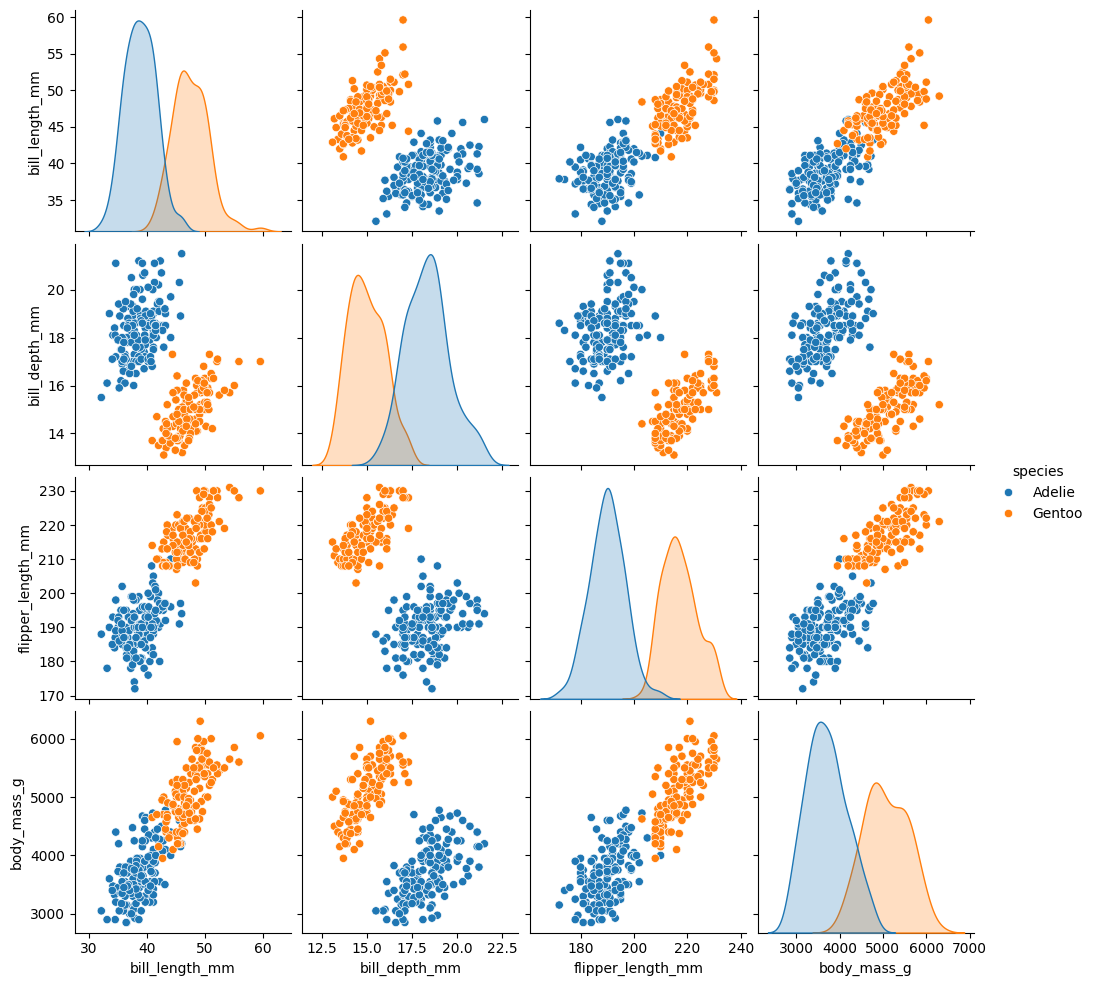

In [ ]:
sns.pairplot(
    df,
    vars=[
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g"
    ],
    hue="species"
)


plt.show()

### **To analyze the categorical features, we create count plots showing the distribution of the two penguin species across the different islands and years. This allows us to investigate whether these categorical variables provide additional information for distinguishing between the two species.**

### **The plots show that the distribution of the species differs across the islands, indicating that the island is a potentially useful feature for classification. In contrast, the distribution across the different years appears to be more similar, suggesting that the year may provide less information for distinguishing between the species.**

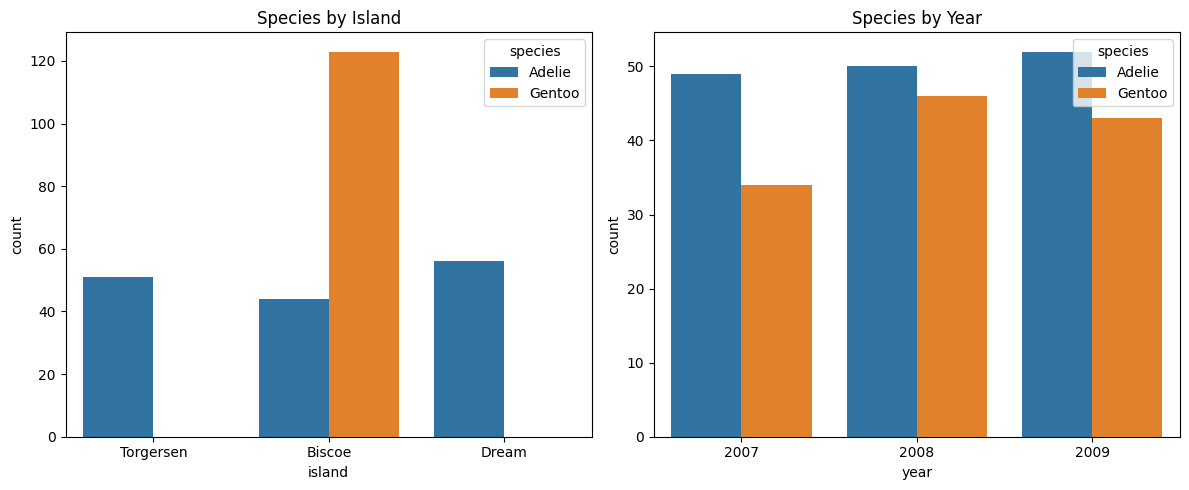

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    data=df,
    x="island",
    hue="species",
    ax=axes[0]
)
axes[0].set_title("Species by Island")

sns.countplot(
    data=df,
    x="year",
    hue="species",
    ax=axes[1]
)
axes[1].set_title("Species by Year")

plt.tight_layout()
plt.show()

### **We separate the target variable from the input features. The first column, species, is used as the target variable y, which contains the class labels we want to predict. The remaining columns are used as the feature matrix X. Finally, the target variable is converted into a NumPy array for use with the classification model.**

In [ ]:
y = df.iloc[:, 0]
y = np.array(y)
X = df.drop(df.columns[0], axis=1)


### **We split the dataset into training and test sets, using 70% of the data for training and 30% for testing. The categorical features island and year are transformed using one-hot encoding, while the numerical features are standardized using StandardScaler.**

### **The preprocessing is fitted only on the training data. The same transformations are then applied to the test data without fitting the preprocessor again. This prevents data leakage and ensures that the test data remains unseen during the training process.**

### **After preprocessing, we train a Logistic Regression model on the transformed training data. The trained model is then used to predict the species of the previously unseen test data. Finally, we evaluate the model using its accuracy score, where a value close to 1 indicates that the model correctly classifies most of the test samples.**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

categorical_features = ["island", "year"]
numerical_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features), ("num", StandardScaler(), numerical_features)])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

model = LogisticRegression()
model.fit(X_train_transformed, y_train)

y_pred = model.predict(X_test_transformed)


print("Model Score:", model.score(X_test_transformed, y_test)) # near 1 is good

Model Score: 1.0


### **To further evaluate the classification model, we visualize the predictions using a confusion matrix. The rows represent the actual species, while the columns represent the predicted species. The diagonal elements correspond to correctly classified samples, whereas the off-diagonal elements represent incorrect predictions.**

### **The confusion matrix provides a detailed overview of the model's classification performance and allows us to see which species, if any, are being misclassified.**



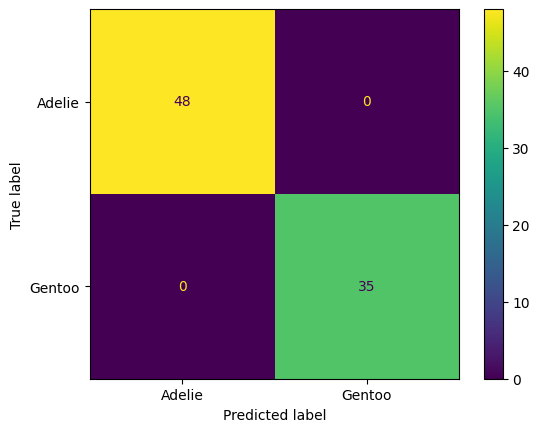

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

### **The confusion matrix shows that all samples in the test set were classified correctly. Therefore, the Logistic Regression model achieved an accuracy of **100%** on the test set, with no misclassified samples.**
